# IMPORT ALL LIBRARIES

In [40]:
# Data handling
import pandas as pd
import numpy as np
# Text cleaning
import re
import string
# NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import spacy
# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLP Resources

In [3]:
# Download stopwords from NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Download POS tagger (one time)
nltk.download('pos_tag')

# Load English stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


# Load SpaCy English model
nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deepa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\deepa/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\deepa/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deepa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\deepa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\deepa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Error loading pos_tag: Package 'pos_tag' not found in
[nltk_data]     index
d:\fack_news_detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. S

# LOAD DATA


In [4]:
fake = pd.read_csv(r"D:\fack_news_detection\news_dataset\Fake.csv")
real = pd.read_csv(r"D:\fack_news_detection\news_dataset\True.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real], ignore_index=True)
df = df[["text", "label"]]

df.head()


,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


# Basic cleaning

In [5]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["eda_text"] = df["text"].apply(basic_clean)


In [6]:
df.eda_text

0        donald trump just couldn t wish all americans ...
1        house intelligence committee chairman devin nu...
2        on friday it was revealed that former milwauke...
3        on christmas day donald trump announced that h...
4        pope francis used his annual christmas day mes...
                               ...                        
44893    brussels reuters  nato allies on tuesday welco...
44894    london reuters  lexisnexis a provider of legal...
44895    minsk reuters  in the shadow of disused soviet...
44896    moscow reuters  vatican secretary of state car...
44897    jakarta reuters  indonesia will buy  sukhoi fi...
Name: eda_text, Length: 44898, dtype: str

# Tokenization

In [7]:
all_words = " ".join(df["eda_text"]).split()

print("Total tokens:", len(all_words))


Total tokens: 17942732


# Word Frequency Distribution

In [8]:
word_freq = Counter(all_words)

freq_df = pd.DataFrame(
    word_freq.items(), columns=["word", "frequency"]
).sort_values(by="frequency", ascending=False)

freq_df.head(10)


,word,frequency
27,the,1010129
20,to,534845
49,of,440784
8,a,408490
12,and,406391
139,in,345299
16,that,237110
269,on,189639
67,s,176478
62,for,171751


# Zipf’s Law Log-Log Plot

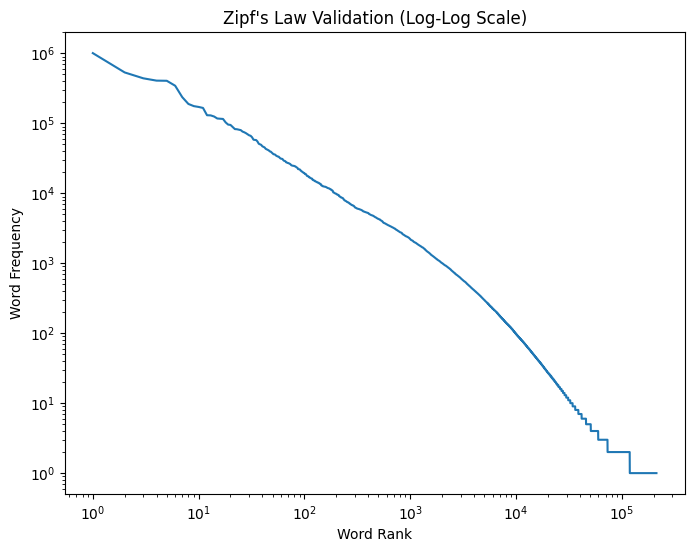

In [9]:
freq_df["rank"] = range(1, len(freq_df) + 1)

plt.figure(figsize=(8,6))
plt.loglog(freq_df["rank"], freq_df["frequency"])
plt.xlabel("Word Rank")
plt.ylabel("Word Frequency")
plt.title("Zipf's Law Validation (Log-Log Scale)")
plt.show()


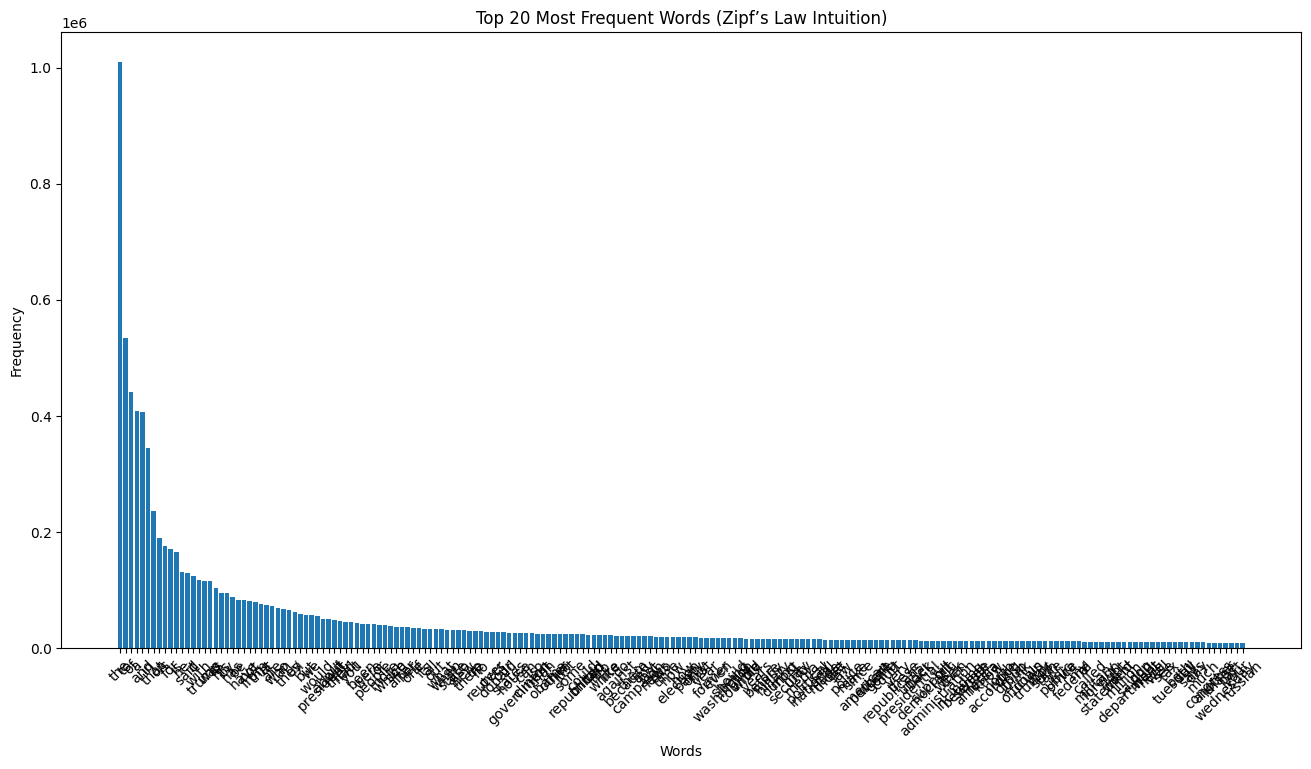

In [10]:
# Top 20 most frequent words
top_words = freq_df.head(200)

plt.figure(figsize=(16,8))
plt.bar(top_words["word"], top_words["frequency"])
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words (Zipf’s Law Intuition)")
plt.show()


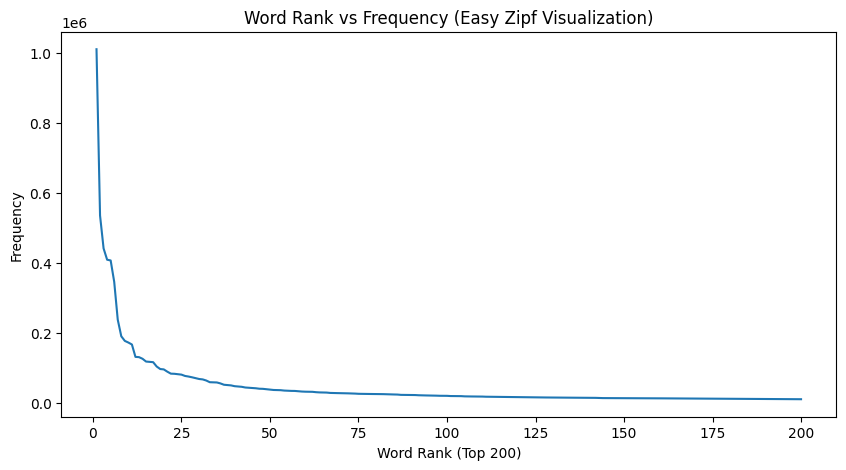

In [11]:
plt.figure(figsize=(10,5))
plt.plot(freq_df["rank"][:200], freq_df["frequency"][:200])
plt.xlabel("Word Rank (Top 200)")
plt.ylabel("Frequency")
plt.title("Word Rank vs Frequency (Easy Zipf Visualization)")
plt.show()


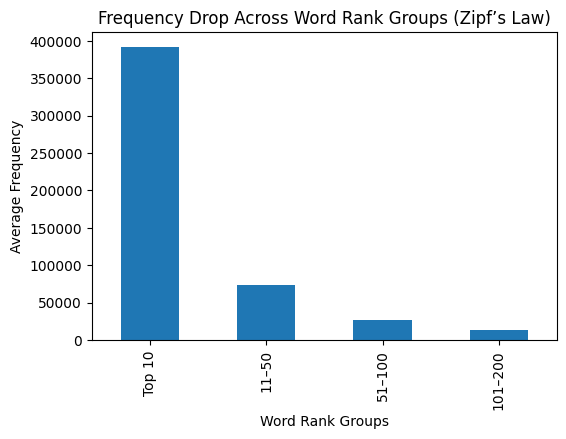

In [12]:
# Take top 200 words
top_200 = freq_df.head(200)

# Create bins of rank
top_200["rank_bin"] = pd.cut(
    top_200["rank"],
    bins=[0,10,50,100,200],
    labels=["Top 10", "11–50", "51–100", "101–200"]
)

# Average frequency per bin
bin_avg = top_200.groupby("rank_bin")["frequency"].mean()

# Plot
plt.figure(figsize=(6,4))
bin_avg.plot(kind="bar")
plt.xlabel("Word Rank Groups")
plt.ylabel("Average Frequency")
plt.title("Frequency Drop Across Word Rank Groups (Zipf’s Law)")
plt.show()


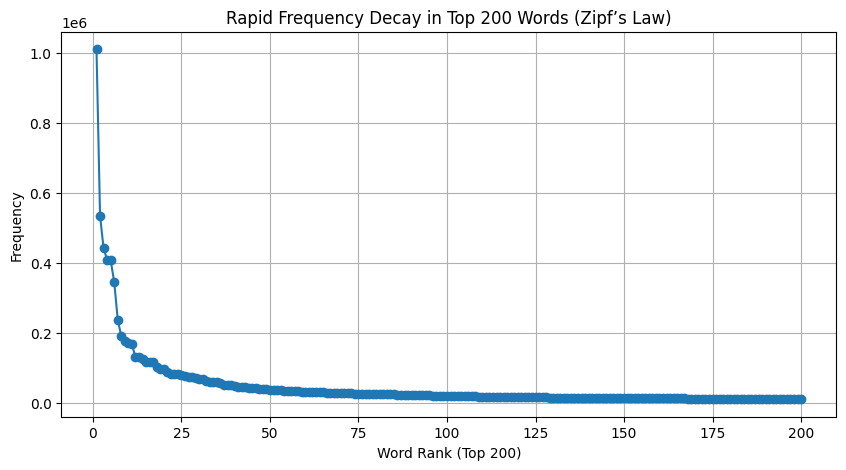

In [13]:
top_200 = freq_df.head(200)

plt.figure(figsize=(10,5))
plt.plot(top_200["rank"], top_200["frequency"], marker="o")
plt.xlabel("Word Rank (Top 200)")
plt.ylabel("Frequency")
plt.title("Rapid Frequency Decay in Top 200 Words (Zipf’s Law)")
plt.grid(True)
plt.show()


# Heaps’ Law Vocabulary Growth

In [14]:
vocab_sizes = []
token_sizes = []

vocab = set()

for i, word in enumerate(all_words):
    vocab.add(word)
    if i % 5000 == 0 and i > 0:
        vocab_sizes.append(len(vocab))
        token_sizes.append(i)


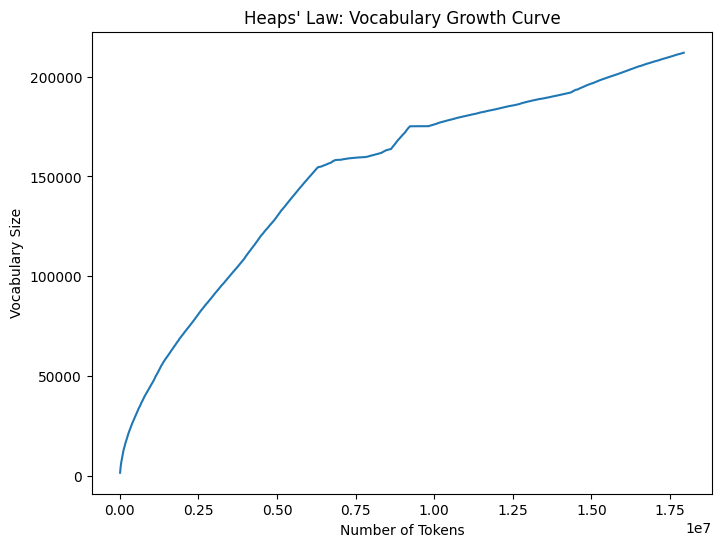

In [15]:
plt.figure(figsize=(8,6))
plt.plot(token_sizes, vocab_sizes)
plt.xlabel("Number of Tokens")
plt.ylabel("Vocabulary Size")
plt.title("Heaps' Law: Vocabulary Growth Curve")
plt.show()


In [16]:
chunk_sizes = []       # number of tokens seen
vocab_sizes = []       # unique words till now

vocab = set()

step = 5000  # har 5000 words pe measure lenge

for i, word in enumerate(all_words, start=1):
    vocab.add(word)
    
    if i % step == 0:
        chunk_sizes.append(i)
        vocab_sizes.append(len(vocab))


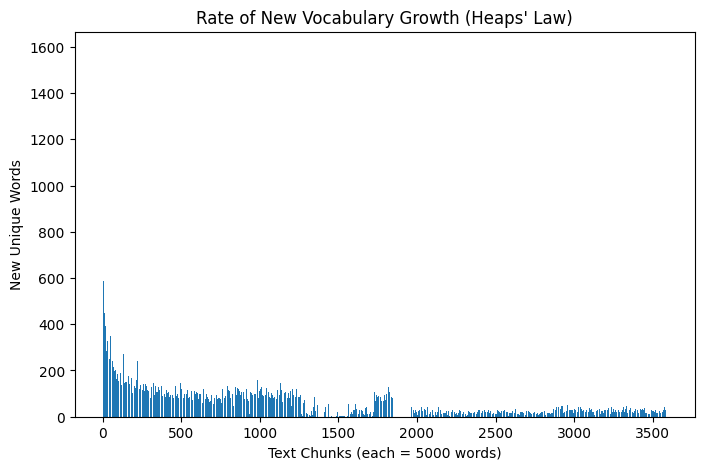

In [17]:
# New words added per chunk
new_words = [vocab_sizes[0]] + [
    vocab_sizes[i] - vocab_sizes[i-1]
    for i in range(1, len(vocab_sizes))
]

plt.figure(figsize=(8,5))
plt.bar(range(len(new_words)), new_words)
plt.xlabel("Text Chunks (each = 5000 words)")
plt.ylabel("New Unique Words")
plt.title("Rate of New Vocabulary Growth (Heaps' Law)")
plt.show()


# TTR for Fake vs Real

 TTR=
 Total Tokens
 /
 Vocabulary Size (Types)

### -Types → unique words

### -Tokens → total words

# News datasets are large

### 1.Large corpus ⇒ TTR naturally very low

### 2.TTR always decreases as corpus size increases

### 3.Values between 0.005 – 0.05 are normal for large text corpora

In [18]:
def type_token_ratio(texts):
    tokens = " ".join(texts).split()
    return len(set(tokens)) / len(tokens)

fake_ttr = type_token_ratio(df[df["label"]==0]["eda_text"])
real_ttr = type_token_ratio(df[df["label"]==1]["eda_text"])

print("Fake News TTR:", fake_ttr)
print("Real News TTR:", real_ttr)


Fake News TTR: 0.0178250027459336
Real News TTR: 0.009615580023192183


# ADVANCED TEXT PREPROCESSING (Model)

In [19]:
# Stopwords list
stop_words = set(stopwords.words("english"))

# Stemming & Lemmatization objects
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def advanced_preprocess(text):
    
    # -----------------------------
    # 1. Convert to string (NaN safety)
    # -----------------------------
    text = str(text)

    # -----------------------------
    # 2. Lowercase
    # -----------------------------
    text = text.lower()

    # -----------------------------
    # 3. Remove URLs
    # -----------------------------
    text = re.sub(r"http\S+|www\S+", "", text)

    # -----------------------------
    # 4. Remove HTML tags
    # -----------------------------
    text = re.sub(r"<.*?>", "", text)

    # -----------------------------
    # 5. Remove emails
    # -----------------------------
    text = re.sub(r"\S+@\S+", "", text)

    # -----------------------------
    # 6. Remove numbers
    # -----------------------------
    text = re.sub(r"\d+", "", text)

    # -----------------------------
    # 7. Remove punctuation
    # -----------------------------
    text = text.translate(str.maketrans("", "", string.punctuation))

    # -----------------------------
    # 8. Remove extra whitespaces
    # -----------------------------
    text = re.sub(r"\s+", " ", text).strip()

    # -----------------------------
    # 9. Tokenization
    # -----------------------------
    tokens = word_tokenize(text)

    # -----------------------------
    # 10. Remove stopwords & short words
    # -----------------------------
    tokens = [
        w for w in tokens
        if w not in stop_words and len(w) > 2
    ]

    # -----------------------------
    # 11. Lemmatization (meaning preserved)
    # -----------------------------
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

# -----------------------------
    # 13. Join tokens back to text
    # -----------------------------
    return " ".join(tokens)


# Apply preprocessing on dataset
df["clean_text"] = df["text"].apply(advanced_preprocess)

# Preview
df[["text", "clean_text"]].head()



,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump wish american happy new year leav...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",friday revealed former milwaukee sheriff david...
3,"On Christmas day, Donald Trump announced that ...",christmas day donald trump announced would bac...
4,Pope Francis used his annual Christmas Day mes...,pope francis used annual christmas day message...


# Heaps Curve: Before vs After Cleaning

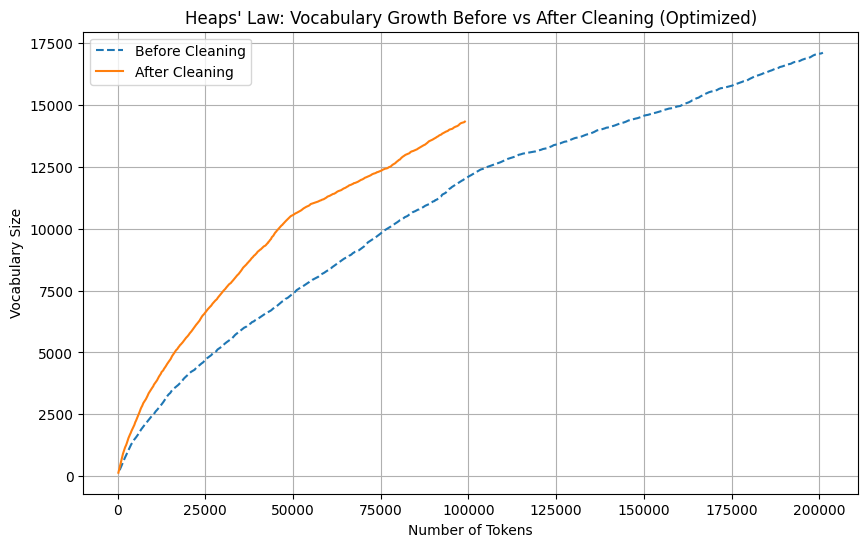

In [20]:
# ================= FAST Heaps' Law Function =================
def heaps_data_fast(text_series, sample_step=100):
    vocab = set()
    token_count = 0

    token_sizes = []
    vocab_sizes = []

    for i, text in enumerate(text_series):
        # Skip some documents to speed up (optional but recommended)
        if i % sample_step != 0:
            continue

        words = nltk.word_tokenize(text.lower())

        for word in words:
            token_count += 1
            vocab.add(word)

        token_sizes.append(token_count)
        vocab_sizes.append(len(vocab))

    return token_sizes, vocab_sizes


# ---------------- BEFORE CLEANING ----------------
tokens_raw, vocab_raw = heaps_data_fast(df["text"], sample_step=100)

# ---------------- AFTER CLEANING -----------------
tokens_clean, vocab_clean = heaps_data_fast(df["clean_text"], sample_step=100)


# ---------------- Visualization ------------------
plt.figure(figsize=(10,6))
plt.plot(tokens_raw, vocab_raw, label="Before Cleaning", linestyle="--")
plt.plot(tokens_clean, vocab_clean, label="After Cleaning")

plt.xlabel("Number of Tokens")
plt.ylabel("Vocabulary Size")
plt.title("Heaps' Law: Vocabulary Growth Before vs After Cleaning (Optimized)")
plt.legend()
plt.grid(True)
plt.show()

# POS Tagging

In [ ]:
# #  POS TAGGING + EDA

# import nltk
# import pandas as pd
# import matplotlib.pyplot as plt


# # Force correct NLTK data path
# nltk_data_dir = os.path.join(os.path.expanduser("~"), "nltk_data")
# os.makedirs(nltk_data_dir, exist_ok=True)

# if nltk_data_dir not in nltk.data.path:
#     nltk.data.path.append(nltk_data_dir)

# #  Download REQUIRED resources 
# nltk.download("punkt", download_dir=nltk_data_dir)
# nltk.download("averaged_perceptron_tagger", download_dir=nltk_data_dir)
# nltk.download("averaged_perceptron_tagger_eng", download_dir=nltk_data_dir)

# # STEP 1: Tokenization 
# df["tokens"] = df["clean_text"].astype(str).apply(nltk.word_tokenize)

# # STEP 2: POS Tagging 
# df["pos_tags"] = df["tokens"].apply(lambda tokens: nltk.pos_tag(tokens))

# #  STEP 3: Flatten POS data for EDA 
# pos_data = [
#     {"word": word, "pos": tag}
#     for doc in df["pos_tags"]
#     for word, tag in doc
# ]

# pos_df = pd.DataFrame(pos_data)

# # STEP 4: POS Frequency 
# pos_freq = pos_df["pos"].value_counts().reset_index()
# pos_freq.columns = ["POS_Tag", "Count"]

# # STEP 5: Visualization 
# plt.figure(figsize=(12,6))
# sns.barplot(x="POS_Tag", y="Count", data=pos_freq)
# plt.xticks(rotation=45)
# plt.title("POS Tag Distribution")
# plt.xlabel("Part of Speech Tag")
# plt.ylabel("Frequency")
# plt.tight_layout()
# plt.show()

# #  STEP 6: Top Words with POS 
# top_words_pos = (
#     pos_df
#     .groupby(["word", "pos"])
#     .size()
#     .reset_index(name="count")
#     .sort_values("count", ascending=False)
#     .head(15)
# )

# display(top_words_pos)


# Spacy POS tagging

In [30]:

# import spacy
# from collections import Counter

# nlp = spacy.load("en_core_web_sm")

# pos_list = []

# for doc in nlp.pipe(df["clean_text"].astype(str), batch_size=50):
#     for token in doc:
#         pos_list.append(token.pos_)

# pos_counts = Counter(pos_list)

# pos_df = pd.DataFrame(pos_counts.items(), columns=["POS_Tag", "Count"])

# plt.figure(figsize=(10,5))
# plt.bar(pos_df["POS_Tag"], pos_df["Count"])
# plt.xticks(rotation=45)
# plt.title("spaCy POS Tag Distribution (Full Dataset)")
# plt.show()


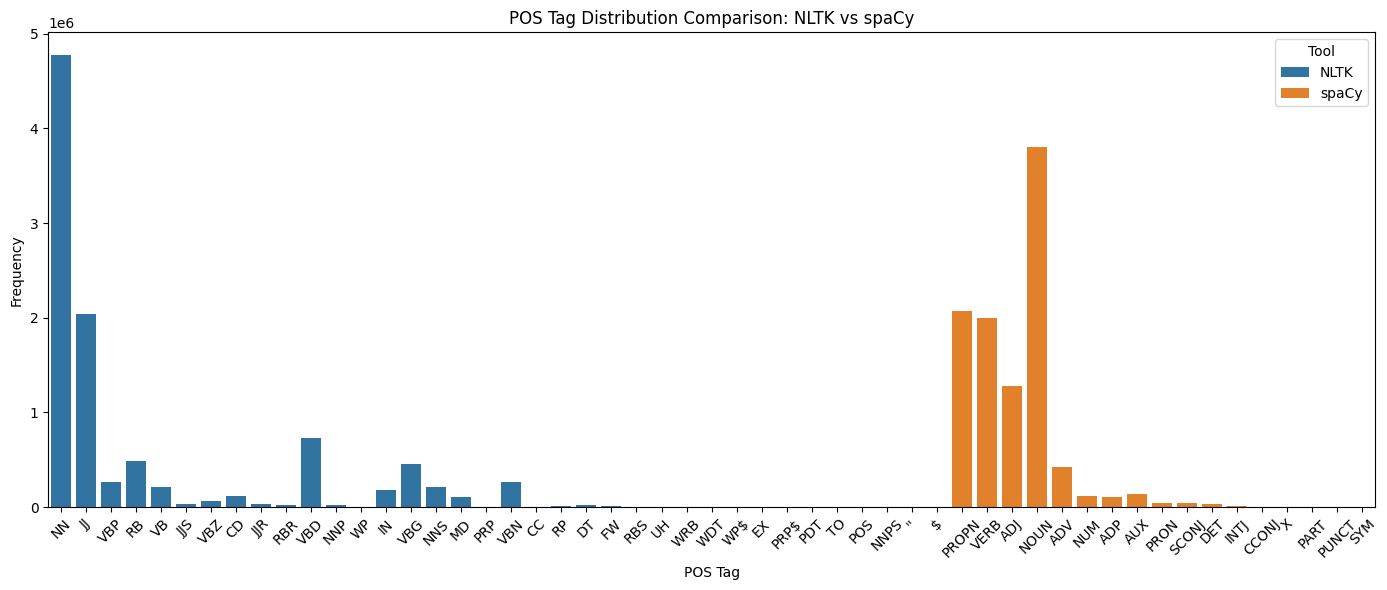

In [27]:
# ================= POS COMPARISON: NLTK vs spaCy =================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import spacy
import nltk

# ---------- NLTK POS COUNTS ----------
nltk_pos_list = [
    tag
    for doc in df["pos_tags"]
    for _, tag in doc
]

nltk_pos_counts = Counter(nltk_pos_list)
nltk_df = pd.DataFrame(nltk_pos_counts.items(), columns=["POS", "Count"])
nltk_df["Tool"] = "NLTK"

# ---------- spaCy POS COUNTS ----------
nlp = spacy.load("en_core_web_sm")

spacy_pos_list = []
for doc in nlp.pipe(df["clean_text"].astype(str), batch_size=50):
    for token in doc:
        spacy_pos_list.append(token.pos_)

spacy_pos_counts = Counter(spacy_pos_list)
spacy_df = pd.DataFrame(spacy_pos_counts.items(), columns=["POS", "Count"])
spacy_df["Tool"] = "spaCy"

# ---------- Combine for Visualization ----------
combined_df = pd.concat([nltk_df, spacy_df])

# ---------- Visualization ----------
plt.figure(figsize=(14,6))
sns.barplot(
    data=combined_df,
    x="POS",
    y="Count",
    hue="Tool"
)

plt.title("POS Tag Distribution Comparison: NLTK vs spaCy")
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Train-Test Split

In [34]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [35]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (35918,)
Test size: (8980,)


# N-Grams + TF-IDF (EXPLICIT LAW BASED)

 ### N-Grams - Context meaning + text representation
 ### TF-IDF - Text representation + Word weightage





In [36]:
# ------------------ STEP 2: TF-IDF with N-grams ------------------
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigram + bigram
    max_df=0.9,           # very common words remove
    min_df=5,             # very rare words remove
    stop_words="english"  # stopwords remove
)

# Fit ONLY on training data (no data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using same vocabulary
X_test_tfidf = tfidf.transform(X_test)

# ------------------ STEP 3: Check Shapes ------------------
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (35918, 237150)
Test shape: (8980, 237150)


# Train Model

# Naive bayes

In [37]:
# Initialize model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train_tfidf, y_train)

# Predict
nb_pred = nb_model.predict(X_test_tfidf)

# Accuracy
nb_acc = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_acc)

# Detailed report
print(classification_report(y_test, nb_pred))





Naive Bayes Accuracy: 0.9527839643652561
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4696
           1       0.95      0.95      0.95      4284

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



# SVM

In [38]:
# Linear SVM (best for text data)
svm_model = LinearSVC()

# Train
svm_model.fit(X_train_tfidf, y_train)

# Predict
svm_pred = svm_model.predict(X_test_tfidf)

# Accuracy
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

# Report
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.994988864142539
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      1.00      0.99      8980
weighted avg       0.99      0.99      0.99      8980



# linear regession

In [41]:
# Linear Regression
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_tfidf, y_train)

# Predict (continuous output)
lr_pred_cont = lr_model.predict(X_test_tfidf)

# Convert continuous output to class (0 / 1)
lr_pred = (lr_pred_cont >= 0.5).astype(int)

# Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
print("Linear Regression Accuracy:", lr_acc)

# Report
print(classification_report(y_test, lr_pred))



Linear Regression Accuracy: 0.995879732739421
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



# MODEL COMPARISON

In [42]:
model_results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "LinearRegression"],
    "Accuracy": [nb_acc, svm_acc, lr_acc]
})

model_results


,Model,Accuracy
0,Naive Bayes,0.952784
1,SVM,0.994989
2,LinearRegression,0.995880


# VISUAL COMPARISON

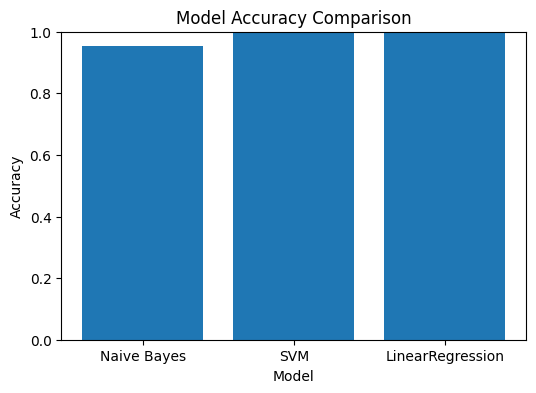

In [43]:
plt.figure(figsize=(6,4))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.ylim(0,1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


# CONFUSION MATRIX (BEST MODEL)

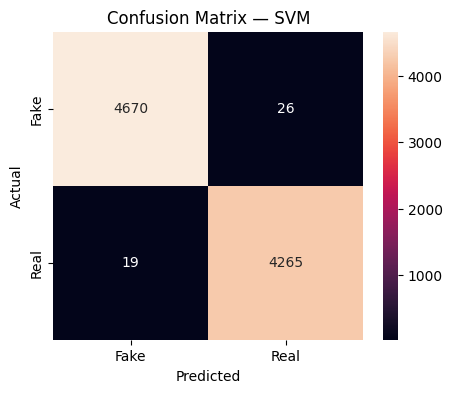

In [44]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SVM")
plt.show()


# USER INPUT PREDICTION FUNCTION

In [49]:
def predict_news(text):
    # preprocess same as training
    cleaned = advanced_preprocess(text)
    vector = tfidf.transform([cleaned])
    prediction = svm_model.predict(vector)

    return "REAL NEWS" if prediction[0] == 1 else "FAKE NEWS"


In [50]:
# Test custom input
news = "Government launches new economic policy to boost growth"
print(predict_news(news))


FAKE NEWS


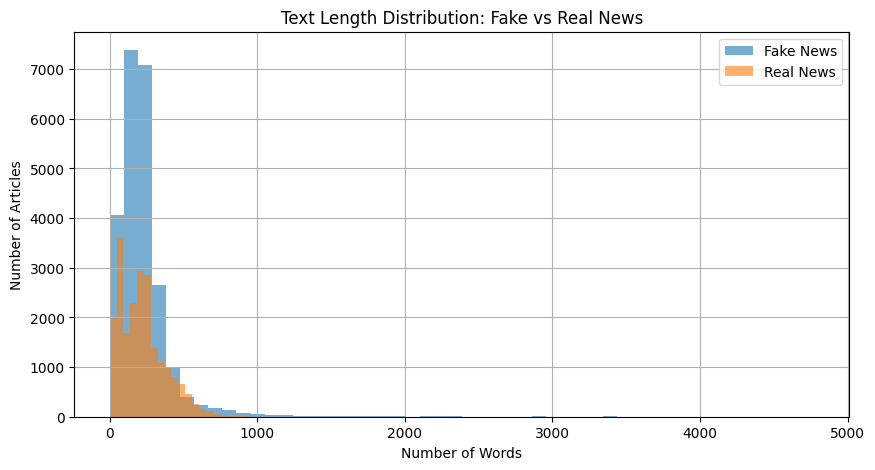

In [52]:
import matplotlib.pyplot as plt

# Text length
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

fake_len = df[df["label"] == 0]["text_length"]
real_len = df[df["label"] == 1]["text_length"]

plt.figure(figsize=(10,5))

plt.hist(fake_len, bins=50, alpha=0.6, label="Fake News")
plt.hist(real_len, bins=50, alpha=0.6, label="Real News")

plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.title("Text Length Distribution: Fake vs Real News")
plt.legend()
plt.grid(True)

plt.show()


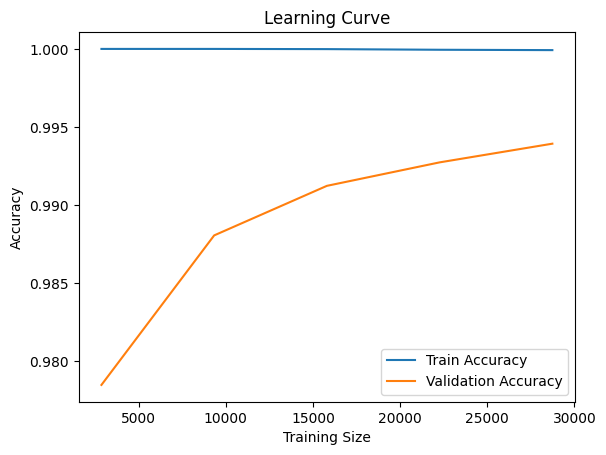

In [60]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Accuracy")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


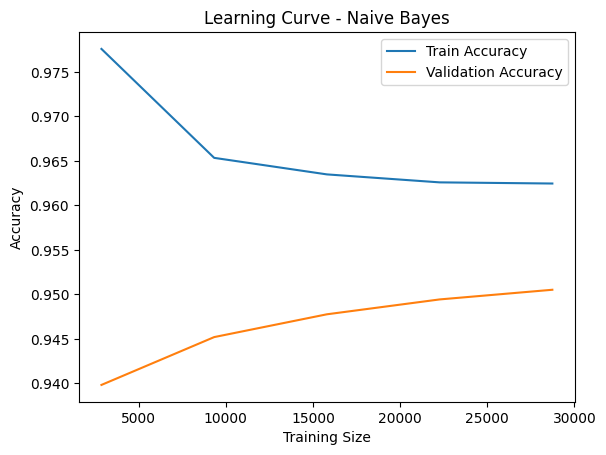

In [66]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    nb_model,              # Naive Bayes model
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Accuracy")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Naive Bayes")
plt.legend()
plt.show()


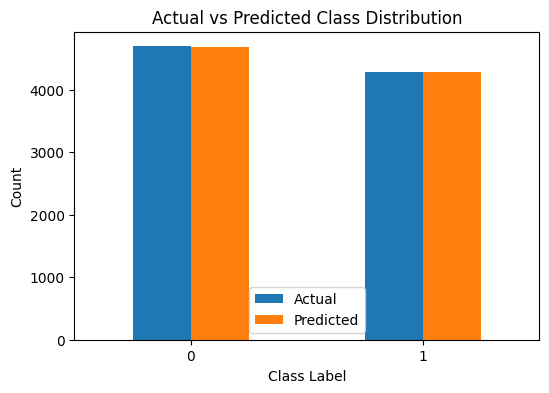

In [64]:
import pandas as pd

compare_df = pd.DataFrame({
    "Actual": y_test.value_counts(),
    "Predicted": pd.Series(y_test_pred).value_counts()
}).fillna(0)

compare_df.plot(kind="bar", figsize=(6,4))
plt.title("Actual vs Predicted Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [68]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(lr_model, "lr_model.pkl")
joblib.dump(nb_model, "nb_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Models saved")



Models saved


In [69]:
def predict_news(text, model):
    cleaned = advanced_preprocess(text)     # same preprocessing
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)

    return "REAL NEWS" if prediction[0] == 1 else "FAKE NEWS"


In [71]:
news = "The following statementsÂ were posted to the verified Twitter accounts of U.S. President Donald Trump, @realDonaldTrump and @POTUS.  The opinions expressed are his own.Â Reuters has not edited the statements or confirmed their accuracy.  @realDonaldTrump : - While the Fake News loves to talk about my so-called low approval rating, @foxandfriends just showed that my rating on Dec. 28, 2017, was approximately the same as President Obama on Dec. 28, 2009, which was 47%...and this despite massive negative Trump coverage & Russia hoax! [0746 EST] - Why is the United States Post Office, which is losing many billions of dollars a year, while charging Amazon and others so little to deliver their packages, making Amazon richer and the Post Office dumber and poorer? Should be charging MUCH MORE! [0804 EST] -- Source link: (bit.ly/2jBh4LU) (bit.ly/2jpEXYR) "

print("SVM:", predict_news(news, svm_model))
print("Logistic Regression:", predict_news(news, lr_model))
print("Naive Bayes:", predict_news(news, nb_model))


SVM: REAL NEWS
Logistic Regression: FAKE NEWS
Naive Bayes: REAL NEWS


# BERT TOKENIZATION PREPARATION

In [ ]:
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# class NewsDataset(Dataset):
#     def __init__(self, texts, labels):
#         self.texts = texts
#         self.labels = labels
    
#     def __len__(self):
#         return len(self.texts)
    
#     def __getitem__(self, idx):
#         encoding = tokenizer(
#             self.texts[idx],
#             truncation=True,
#             padding="max_length",
#             max_length=256,
#             return_tensors="pt"
#         )
#         return {
#             "input_ids": encoding["input_ids"].flatten(),
#             "attention_mask": encoding["attention_mask"].flatten(),
#             "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        # }

# TRAIN-TEST SPLIT


In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     df["clean_text"].tolist(),
#     df["label"].tolist(),
#     test_size=0.2,
#     random_state=42
# )

# train_dataset = NewsDataset(X_train, y_train)
# test_dataset = NewsDataset(X_test, y_test)

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=8)

## LOAD BERT MODEL

In [ ]:
# device = "cuda" if torch.cuda.is_available() else "cpu"

# model = BertForSequenceClassification.from_pretrained(
#     "bert-base-uncased",
#     num_labels=2
# ).to(device)
# print(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# TRAINING LOOP

In [ ]:
# optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# epochs = 8 

# print("Training Started...")

# for epoch in range(epochs):
#     model.train()
#     for batch in train_loader:
#         optimizer.zero_grad()
        
#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["labels"].to(device)

#         output = model(
#             input_ids,
#             attention_mask=attention_mask,
#             labels=labels
#         )

#         loss = output.loss
#         loss.backward()
#         optimizer.step()

#     print(f"Epoch {epoch+1} Loss:", loss.item())
